# 🧬 Genetic Algorithms: A Visual Introduction
### Inspired by Darwin's Theory of Evolution

Genetic Algorithms (GAs) are **nature-inspired search and optimisation algorithms** that mimic
the process of biological evolution. First formalised by **John Holland** in the 1970s at the
University of Michigan, they have since become one of the most versatile tools in computer science,
operations research, and engineering.

---

## What Is a Genetic Algorithm?

At their core, GAs maintain a **population of candidate solutions** and evolve it over time using
operators borrowed from biology:

| Operator | Biology | GA |
|---|---|---|
| **Selection** | Fit organisms survive and reproduce | Better solutions are chosen as parents |
| **Crossover** | Children inherit traits from both parents | Two solutions combine to form a new one |
| **Mutation** | DNA copying errors introduce novelty | Small random tweaks explore new regions |
| **Elitism** | Dominant genes persist | The very best solutions are preserved intact |

Unlike calculus-based methods that follow gradients, a GA only needs to *evaluate* how good a
solution is — it does **not** need to know *why* it is good or in which direction to improve.
This makes GAs applicable to a huge range of problems.

---

## Why Not Just Use Gradient Descent?

| Method | Requires | Best for | Weakness |
|---|---|---|---|
| **Gradient Descent** | Differentiable objective | Smooth, continuous spaces | Stuck in local optima |
| **Genetic Algorithm** | Only a fitness function | Discrete, rugged, multi-modal spaces | Slower; stochastic |
| **Brute Force** | Nothing | Tiny search spaces | Computationally infeasible |
| **Simulated Annealing** | Single-solution neighbourhood | Single-objective, sequential | Less parallelism |

GAs shine when:
- The search space is **combinatorial** (orderings, schedules, binary strings)
- The objective function is **non-differentiable** or has many **local optima**
- You want to **explore broadly** rather than exploit a single promising region
- Multiple cores can evaluate solutions **in parallel**

---

## The Problem We'll Solve: Travelling Salesman Problem (TSP)
> *"A salesman must visit every city exactly once and return home.
>  What is the **shortest** possible route?"*

This is a classic *NP-hard* problem — brute-forcing 15 cities would require checking
**15! ≈ 1.3 trillion** routes. GAs find excellent solutions in seconds.

---

## The Five Stages of a Genetic Algorithm

| Stage | Biological Analogy | What happens |
|---|---|---|
| 1️⃣ **Initialisation** | First generation | Create random candidate routes |
| 2️⃣ **Fitness Evaluation** | Survival pressure | Score each route (shorter = fitter) |
| 3️⃣ **Selection** | "Survival of the fittest" | Choose better routes as parents |
| 4️⃣ **Crossover** | Reproduction | Combine two parents into a child |
| 5️⃣ **Mutation** | Random genetic change | Tweak routes to maintain diversity |

Then **repeat** until satisfied with the result!

> **Vocabulary:** Each candidate solution is called an **individual** or **chromosome**.
> A collection of individuals is the **population**.
> One pass through stages 2–5 is one **generation**.
> The score assigned to an individual is its **fitness**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import random
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FAFB',
    'grid.alpha':      0.35,
    'font.size':       11,
    'axes.titlesize':  13,
    'axes.titleweight':'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Colour palette ───────────────────────────────────────────────────────────
BLUE   = '#2196F3'
RED    = '#F44336'
GREEN  = '#4CAF50'
ORANGE = '#FF9800'
PURPLE = '#9C27B0'
GOLD   = '#FFC107'
DARK   = '#37474F'

print('✅  All libraries loaded.')
print(f'   numpy      {np.__version__}')
print(f'   matplotlib {plt.matplotlib.__version__}')


✅  All libraries loaded.
   numpy      2.3.2
   matplotlib 3.10.6


In [2]:
# ============================================================
#  Core Genetic Algorithm Functions
# ============================================================

def total_distance(route, cities):
    """Total round-trip distance for a route."""
    n = len(route)
    return sum(
        np.linalg.norm(cities[route[i]] - cities[route[(i + 1) % n]])
        for i in range(n)
    )

def fitness(route, cities):
    """Fitness = 1 / distance  (higher is better)."""
    return 1.0 / total_distance(route, cities)

def create_route(n_cities):
    """Random permutation of city indices."""
    r = list(range(n_cities))
    random.shuffle(r)
    return r

def create_population(pop_size, n_cities):
    """Initialise a random population."""
    return [create_route(n_cities) for _ in range(pop_size)]

def tournament_selection(population, fitnesses, k=5):
    """Pick k random individuals; return a copy of the fittest."""
    contestants = random.sample(list(range(len(population))), k)
    winner = max(contestants, key=lambda i: fitnesses[i])
    return population[winner][:]

def ordered_crossover(p1, p2):
    """Ordered Crossover (OX-1): inherits a slice from p1,
    fills the rest from p2 in order."""
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a:b] = p1[a:b]
    remaining = [c for c in p2 if c not in child[a:b]]
    j = 0
    for i in range(n):
        if child[i] is None:
            child[i] = remaining[j]
            j += 1
    return child

def swap_mutation(route, rate=0.015):
    """Swap two random cities with probability `rate` per gene."""
    route = route[:]
    n = len(route)
    for i in range(n):
        if random.random() < rate:
            j = random.randint(0, n - 1)
            route[i], route[j] = route[j], route[i]
    return route

def run_ga(cities, pop_size=150, generations=300,
           mutation_rate=0.015, tournament_k=5, elite_size=15,
           snapshot_gens=None):
    """Run the full Genetic Algorithm.

    Returns
    -------
    best_route   : list of city indices
    history      : dict with 'best_distances' and 'avg_distances'
    snapshots    : dict {generation: best_route_at_that_gen}
    """
    if snapshot_gens is None:
        snapshot_gens = set()
    else:
        snapshot_gens = set(snapshot_gens)

    n_cities   = len(cities)
    population = create_population(pop_size, n_cities)

    best_distances, avg_distances = [], []
    snapshots = {}
    overall_best, overall_best_dist = None, float('inf')

    for gen in range(generations):
        distances = [total_distance(r, cities) for r in population]
        fitnesses = [1.0 / d for d in distances]

        best_idx = int(np.argmin(distances))
        if distances[best_idx] < overall_best_dist:
            overall_best_dist = distances[best_idx]
            overall_best      = population[best_idx][:]

        best_distances.append(overall_best_dist)
        avg_distances.append(float(np.mean(distances)))

        if gen in snapshot_gens:
            snapshots[gen] = population[best_idx][:]

        # ── Next generation ──────────────────────────────────────────────
        ranked    = sorted(range(pop_size), key=lambda i: distances[i])
        elite     = [population[i][:] for i in ranked[:elite_size]]
        children  = []
        while len(children) < pop_size - elite_size:
            p1    = tournament_selection(population, fitnesses, tournament_k)
            p2    = tournament_selection(population, fitnesses, tournament_k)
            child = ordered_crossover(p1, p2)
            child = swap_mutation(child, mutation_rate)
            children.append(child)

        population = elite + children

    return overall_best, {'best_distances': best_distances,
                          'avg_distances':  avg_distances}, snapshots

print('✅  All GA functions defined.')


✅  All GA functions defined.


## 🗺️  The Problem: 15 Cities, Infinite Possible Routes

With 15 cities there are **15! ≈ 1.3 trillion** possible routes.
We can't check them all — but a Genetic Algorithm can find a great solution fast.

### Why is TSP so Hard?
The number of routes grows **factorially** with the number of cities:

| Cities | Routes | Time to brute-force (at 1 billion checks/sec) |
|---|---|---|
| 5 | 60 | Instant |
| 10 | 181,440 | < 1 ms |
| 15 | ~654 billion | ~10 minutes |
| 20 | ~1.2 × 10¹⁷ | ~3,800 years |
| 30 | ~4.4 × 10³⁰ | longer than the age of the universe |

This exponential blowup is why heuristics like GAs are necessary for real-world routing
problems (delivery networks, circuit board drilling, genome sequencing, etc.).

### Representing a Solution as a Chromosome
In our GA, each **chromosome** is simply a list of city indices — a **permutation**:

```
[0, 7, 3, 12, 5, 9, 1, 14, 8, 6, 2, 11, 4, 13, 10]
  ↑                                               ↑
Start city                               Last city (then back to 0)
```

The GA searches over the space of all such permutations to find the shortest round trip.


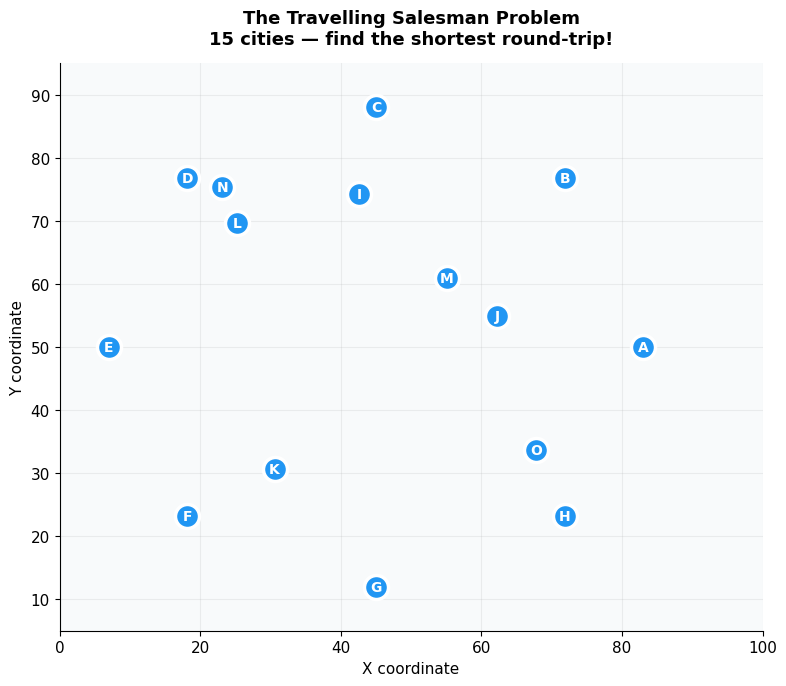

Number of possible routes: 1,307,674,368,000
That would take a long time to check one-by-one...


In [3]:
# ── City layout ─────────────────────────────────────────────────────────────
NUM_CITIES = 15
np.random.seed(SEED)

# A ring of 8 outer cities + 7 inner cities for a visually interesting map
angles      = np.linspace(0, 2 * np.pi, 8, endpoint=False)
outer       = np.column_stack([45 + 38 * np.cos(angles),
                               50 + 38 * np.sin(angles)])
inner       = np.random.rand(7, 2) * 55 + 22
cities      = np.vstack([outer, inner])

CITY_LABELS = [chr(65 + i) for i in range(NUM_CITIES)]   # A, B, C, …

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(cities[:, 0], cities[:, 1],
           s=300, c=BLUE, zorder=5, edgecolors='white', linewidth=2.5)

for i, (x, y) in enumerate(cities):
    ax.annotate(CITY_LABELS[i], (x, y),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white', zorder=6)

ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
ax.set_title(f'The Travelling Salesman Problem\n'
             f'{NUM_CITIES} cities — find the shortest round-trip!', pad=14)
ax.set_xlabel('X coordinate');  ax.set_ylabel('Y coordinate')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('01_cities.png', dpi=150, bbox_inches='tight')
plt.show()

from math import factorial
print(f'Number of possible routes: {factorial(NUM_CITIES):,}')
print(f'That would take a long time to check one-by-one...')


## Stage 1️⃣ — Initialisation: Create a Random Population

We start by generating a **population** of completely random routes.
Think of these as the very first generation — no knowledge yet, just raw variety.

### Why Start Randomly?
Random initialisation ensures we **sample broadly** from the search space.
If we started with similar solutions, the GA might converge prematurely to a local optimum
before it has had a chance to discover better regions of the search landscape.

### Population Size Trade-off
| Small population | Large population |
|---|---|
| Faster per generation | Slower per generation |
| Less genetic diversity | More genetic diversity |
| Higher risk of premature convergence | Explores more solutions |
| Fewer fitness evaluations | Better chance of finding the global optimum |

A population of **150 routes** is a good balance for 15 cities.

### What Does "Diversity" Mean Here?
Diversity refers to how *different* the solutions in the population are from one another.
High diversity = the GA is exploring many different regions of the search space.
Low diversity = the population has converged on similar solutions (which may be good or bad).

**Key insight:** We need *enough* diversity in the initial population so evolution has
meaningful variety to work with. Without it, crossover produces copies, not innovations.


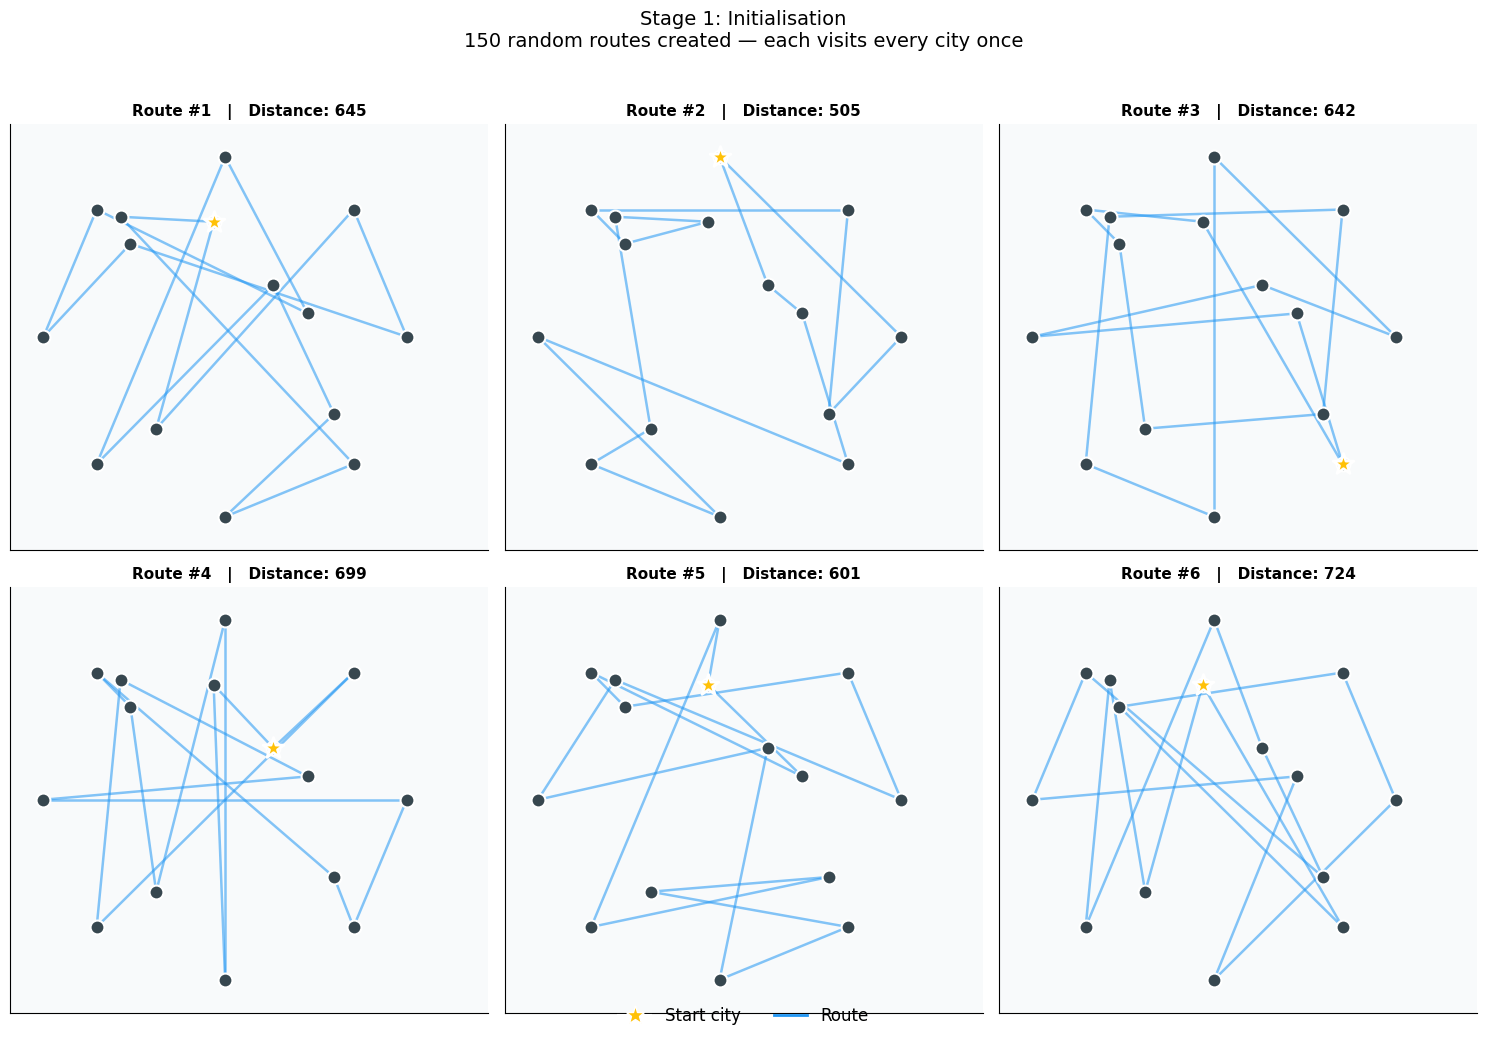

Population of 150 routes created.
Distances range from 505 to 832


In [4]:
# Create initial population of 150 random routes
random.seed(SEED);  np.random.seed(SEED)
population = create_population(150, NUM_CITIES)

# ── Show 6 random routes ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx in range(6):
    ax    = axes[idx]
    route = population[idx]
    dist  = total_distance(route, cities)

    # Draw route edges
    for i in range(NUM_CITIES):
        a, b = cities[route[i]], cities[route[(i + 1) % NUM_CITIES]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=BLUE, alpha=0.55, linewidth=1.8,
                solid_capstyle='round')

    # Cities
    ax.scatter(cities[:, 0], cities[:, 1],
               s=100, c=DARK, zorder=5, edgecolors='white', linewidth=1.5)

    # Start city (gold star)
    start = cities[route[0]]
    ax.scatter([start[0]], [start[1]], s=250, c=GOLD, zorder=6,
               edgecolors='white', linewidth=2, marker='*')

    ax.set_title(f'Route #{idx + 1}   |   Distance: {dist:.0f}', fontsize=11)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])

leg = [Line2D([0], [0], marker='*', color='w', markerfacecolor=GOLD,
              markersize=14, label='Start city'),
       Line2D([0], [0], color=BLUE, linewidth=2, label='Route')]
fig.legend(handles=leg, loc='lower center', ncol=2, frameon=False,
           fontsize=12, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Stage 1: Initialisation\n'
             '150 random routes created — each visits every city once',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('02_initial_population.png', dpi=150, bbox_inches='tight')
plt.show()

distances_init = [total_distance(r, cities) for r in population]
print(f'Population of {len(population)} routes created.')
print(f'Distances range from {min(distances_init):.0f} to {max(distances_init):.0f}')


## Stage 2️⃣ — Fitness Evaluation: Score Every Route

We need a way to rank solutions. The **fitness function** maps a route to a score:

$$\text{fitness} = \frac{1}{\text{total distance}}$$

Shorter route → higher fitness → more likely to survive and reproduce.

### Why Invert the Distance?
GAs typically *maximise* fitness. Since we want to *minimise* distance, we flip it.
The inverse has a nice property: very short routes get disproportionately high fitness,
creating strong selection pressure toward excellent solutions.

### The Fitness Landscape
Imagine plotting fitness as a landscape over all possible routes.
- **Peaks** are excellent routes (short distance)
- **Valleys** are poor routes (long distance)
- The GA is searching this landscape, trying to climb to the highest peak

Real fitness landscapes for TSP have **millions of local optima** — many peaks that are
good but not the best. This is exactly where GAs (with their population of explorers)
outperform single-solution hill-climbing methods.

### Fitness vs. Objective
| Term | Meaning |
|---|---|
| **Objective** | What you're optimising (e.g., total distance) |
| **Fitness** | The score the GA uses (derived from the objective) |
| **Fitness function** | The formula that converts objective → fitness |

The fitness function is the *only* way the GA "understands" the problem.
A well-designed fitness function is crucial — a bad one leads to wrong solutions.

> **In the chart below:** the x-axis ranks routes from worst to best.
> Notice how most random routes cluster around similar (poor) distances,
> while a handful are significantly better — those are the genes worth preserving.


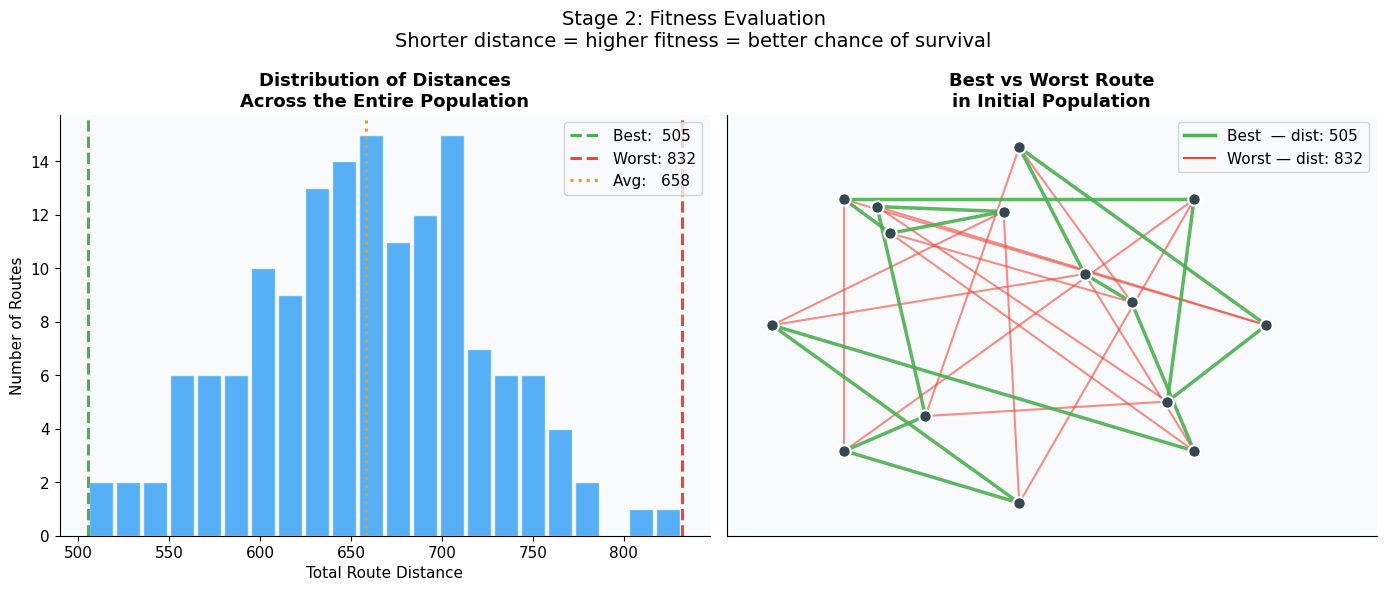

In [5]:
distances_init = [total_distance(r, cities) for r in population]
fitnesses_init = [1.0 / d for d in distances_init]

best_idx  = int(np.argmin(distances_init))
worst_idx = int(np.argmax(distances_init))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Distance histogram ─────────────────────────────────────────────────
ax = axes[0]
ax.hist(distances_init, bins=22, color=BLUE, alpha=0.75, edgecolor='white',
        rwidth=0.9)
ax.axvline(distances_init[best_idx],  color=GREEN,  linewidth=2.2,
           linestyle='--', label=f'Best:  {distances_init[best_idx]:.0f}')
ax.axvline(distances_init[worst_idx], color=RED,    linewidth=2.2,
           linestyle='--', label=f'Worst: {distances_init[worst_idx]:.0f}')
ax.axvline(np.mean(distances_init),   color=ORANGE, linewidth=2.2,
           linestyle=':',  label=f'Avg:   {np.mean(distances_init):.0f}')
ax.set_xlabel('Total Route Distance')
ax.set_ylabel('Number of Routes')
ax.set_title('Distribution of Distances\nAcross the Entire Population')
ax.legend(fontsize=11)

# ── Right: Best vs Worst routes ──────────────────────────────────────────────
ax = axes[1]

def draw_route(ax, route, color, lw=1.8, alpha=0.75):
    n = len(route)
    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=color, alpha=alpha, linewidth=lw,
                solid_capstyle='round')

draw_route(ax, population[worst_idx], RED,   lw=1.5, alpha=0.6)
draw_route(ax, population[best_idx],  GREEN, lw=2.5, alpha=0.9)
ax.scatter(cities[:, 0], cities[:, 1],
           s=80, c=DARK, zorder=5, edgecolors='white', linewidth=1.5)

leg2 = [Line2D([0], [0], color=GREEN, linewidth=2.5,
               label=f'Best  — dist: {distances_init[best_idx]:.0f}'),
        Line2D([0], [0], color=RED,   linewidth=1.5,
               label=f'Worst — dist: {distances_init[worst_idx]:.0f}')]
ax.legend(handles=leg2, fontsize=11)
ax.set_title('Best vs Worst Route\nin Initial Population')
ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
ax.set_xticks([]);    ax.set_yticks([])

fig.suptitle('Stage 2: Fitness Evaluation\n'
             'Shorter distance = higher fitness = better chance of survival',
             fontsize=14)
plt.tight_layout()
plt.savefig('03_fitness_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## Stage 3️⃣ — Selection: Survival of the Fittest

**Selection** determines which individuals get to reproduce. The goal is to give
*better* individuals a *higher chance* of passing on their genes — while still
allowing some weaker ones through to maintain diversity.

### Tournament Selection (our method)
1. Pick **k = 5** random individuals from the population
2. The one with the **shortest route wins** and becomes a parent
3. Repeat to get a second parent

This is called *tournament selection* because individuals compete in a small "tournament."

**Why tournament selection?**
- Simple and efficient — no need to sort the entire population
- The parameter *k* controls **selection pressure**:
  - Small *k* → weak pressure → more diversity (slower convergence)
  - Large *k* → strong pressure → less diversity (faster but riskier convergence)

### Alternative Selection Strategies

| Method | How it works | Pros | Cons |
|---|---|---|---|
| **Tournament** | Best of k random competitors wins | Simple, tunable | Requires k parameter |
| **Roulette Wheel** | Probability ∝ fitness value | Classic, intuitive | Dominated by super-fit individuals |
| **Rank Selection** | Probability ∝ rank, not raw fitness | Stable selection pressure | Ignores magnitude of differences |
| **Elitism** | Top N individuals survive unchanged | Never loses best solution | Can reduce diversity |

We also use **elitism**: the best 15 routes are automatically copied to the next
generation unchanged, ensuring we never accidentally discard a great solution.

> **Think of it this way:** Natural selection doesn't guarantee the strongest animal
> *always* survives — a lion can be beaten by circumstances. But on average, stronger
> animals survive more often. The same is true here.


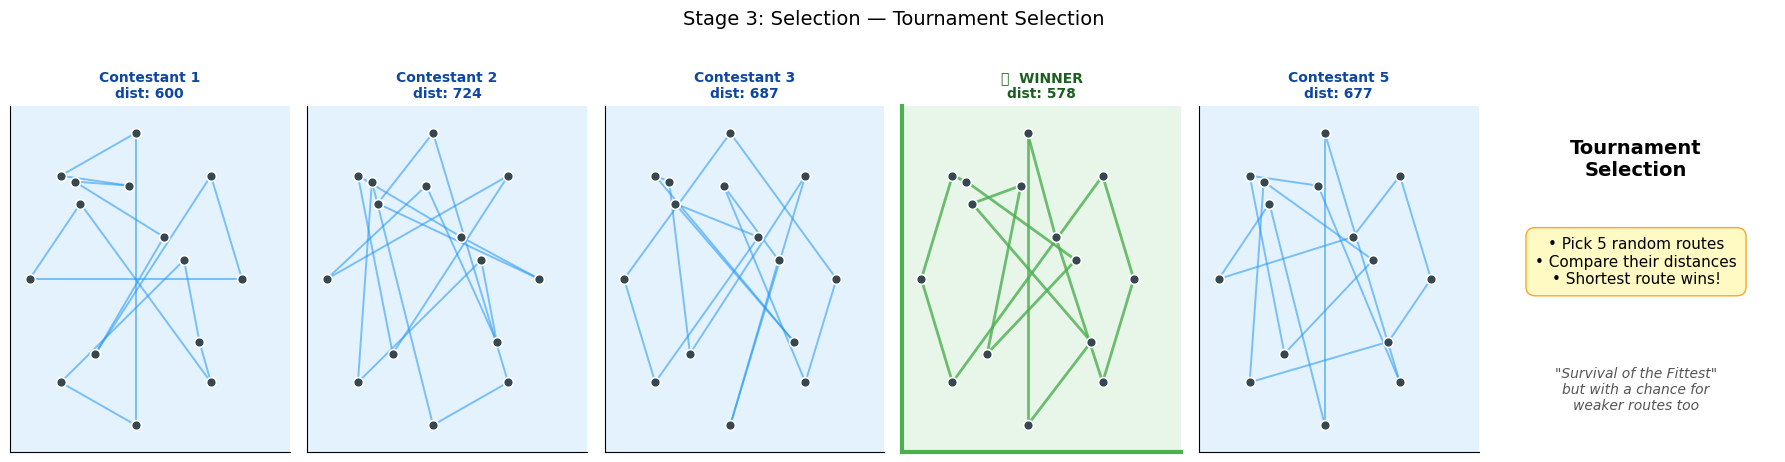

In [6]:
random.seed(7)   # fixed seed so the tournament looks interesting

TOURNAMENT_K = 5
contestants  = random.sample(range(len(population)), TOURNAMENT_K)
t_routes     = [population[i] for i in contestants]
t_distances  = [distances_init[i] for i in contestants]
winner_local = int(np.argmin(t_distances))

fig, axes = plt.subplots(1, TOURNAMENT_K + 1, figsize=(18, 4.5))

for j, (idx, route, dist) in enumerate(zip(contestants, t_routes, t_distances)):
    ax        = axes[j]
    is_winner = (j == winner_local)
    fc        = '#E8F5E9' if is_winner else '#E3F2FD'
    ax.set_facecolor(fc)

    draw_route(ax, route,
               GREEN if is_winner else BLUE,
               lw=2 if is_winner else 1.4,
               alpha=0.8 if is_winner else 0.55)
    ax.scatter(cities[:, 0], cities[:, 1],
               s=50, c=DARK, zorder=5, edgecolors='white', linewidth=1.2)

    title_txt = ('🏆  WINNER\n' if is_winner else f'Contestant {j + 1}\n')
    title_col = '#1B5E20' if is_winner else '#0D47A1'
    ax.set_title(f'{title_txt}dist: {dist:.0f}', color=title_col, fontsize=10)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])
    if is_winner:
        for spine in ax.spines.values():
            spine.set_edgecolor(GREEN);  spine.set_linewidth(3)

# Explanation panel
ax = axes[-1]
ax.axis('off')
ax.text(0.5, 0.80, 'Tournament\nSelection', ha='center', fontsize=14,
        fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.55,
        f'• Pick {TOURNAMENT_K} random routes\n'
        '• Compare their distances\n'
        '• Shortest route wins!',
        ha='center', va='center', fontsize=11, transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.6', fc='#FFF9C4', ec='#F9A825'))
ax.text(0.5, 0.18, '"Survival of the Fittest"\nbut with a chance for\nweaker routes too',
        ha='center', va='center', fontsize=10, style='italic',
        color='#555', transform=ax.transAxes)

fig.suptitle('Stage 3: Selection — Tournament Selection',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('04_selection.png', dpi=150, bbox_inches='tight')
plt.show()


## Stage 4️⃣ — Crossover: Combining Two Parents

**Crossover** (also called *recombination*) creates a new child solution by combining
genetic material from two parents. It's the primary way a GA **exploits** good solutions
found so far — mixing sub-sequences that seem to work well.

### Why Standard Crossover Fails for TSP
If we naively swapped genes (like we might for a binary string), we'd produce **invalid routes**:

```
Parent 1: [0, 2, 4, 6, 8, 10, 12]
Parent 2: [3, 7, 1, 5, 9, 11, 0]
Naive child: [0, 7, 4, 5, 8, 11, 12]   ← city 8 appears once, city 1 missing!
```

For TSP, every city must appear **exactly once**. We need a smarter operator.

### Ordered Crossover (OX-1) — Our Method

1. **Copy a random segment** from Parent 1 into the child
2. **Fill the remaining positions** with cities from Parent 2, reading left-to-right,
   skipping any city already in the child

```
Parent 1: [A, B | C, D, E | F, G]     ← segment [C, D, E] copied directly
Parent 2: [C, F,   A, G, D,   B, E]   ← read in order, skip C, D, E
Child:    [G, B | C, D, E | A, F]     ← remaining slots filled from P2
```

Result: a **valid permutation** that inherits a contiguous sub-route from P1
and the remaining cities in the relative order they appear in P2.

### Other Crossover Variants for Permutation Problems
| Method | Key idea |
|---|---|
| **OX-1 (Ordered Crossover)** | Preserve relative order of Parent 2 |
| **PMX (Partially Mapped)** | Preserve absolute positions of Parent 1 |
| **Cycle Crossover** | Preserve absolute positions of both parents |
| **Edge Recombination** | Preserve edges (city connections) from both parents |

> **Key insight:** The choice of crossover operator should match the structure of the problem.
> For TSP, preserving relative city order (OX-1) or city connections (edge recombination)
> tends to work well because good sub-routes are made of *connected cities*, not isolated genes.


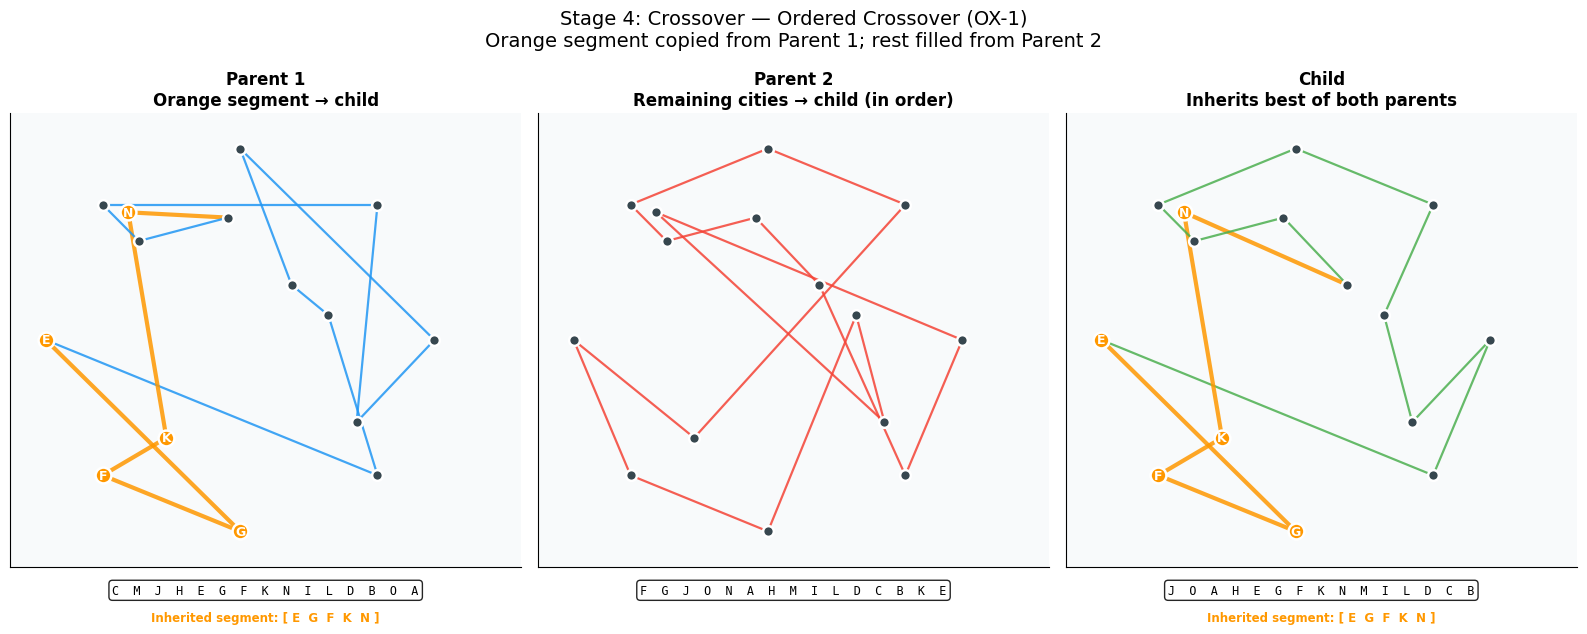

Parent 1 distance: 505
Parent 2 distance: 520
Child distance:    450


In [7]:
random.seed(SEED)
# Use two reasonably good routes for a clear demo
sorted_pop = sorted(range(len(population)),
                    key=lambda i: distances_init[i])
p1 = population[sorted_pop[0]][:]   # best
p2 = population[sorted_pop[2]][:]   # third best

# Fixed crossover window for clarity
CX_A, CX_B = 4, 9

# Perform OX manually so we can highlight
child = [None] * NUM_CITIES
child[CX_A:CX_B] = p1[CX_A:CX_B]
remaining = [c for c in p2 if c not in child[CX_A:CX_B]]
j = 0
for i in range(NUM_CITIES):
    if child[i] is None:
        child[i] = remaining[j];  j += 1

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))

def draw_route_cx(ax, route, base_color, title,
                  seg_start=None, seg_end=None, seg_color=ORANGE):
    """Draw route; highlight crossover segment in seg_color."""
    n = len(route)
    for i in range(n):
        a, b  = cities[route[i]], cities[route[(i + 1) % n]]
        in_cx = (seg_start is not None) and (seg_start <= i < seg_end)
        c  = seg_color if in_cx else base_color
        lw = 3.0       if in_cx else 1.6
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=c, alpha=0.85, linewidth=lw, solid_capstyle='round')

    for k in range(n):
        x, y   = cities[k]
        in_cx  = (seg_start is not None and k in route[seg_start:seg_end])
        fc     = seg_color if in_cx else DARK
        size   = 130       if in_cx else 60
        ax.scatter(x, y, s=size, c=fc, zorder=5,
                   edgecolors='white', linewidth=1.8)
        if in_cx:
            ax.annotate(CITY_LABELS[k], (x, y),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white', zorder=6)

    ax.set_title(title, fontsize=12);
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])

draw_route_cx(axes[0], p1, BLUE,
              f'Parent 1\nOrange segment → child',
              seg_start=CX_A, seg_end=CX_B)

draw_route_cx(axes[1], p2, RED,
              f'Parent 2\nRemaining cities → child (in order)',
              seg_start=None,  seg_end=None)

draw_route_cx(axes[2], child, GREEN,
              f'Child\nInherits best of both parents',
              seg_start=CX_A, seg_end=CX_B)

# Chromosome bar beneath each panel
for ax, route in zip(axes, [p1, p2, child]):
    label = '  '.join([CITY_LABELS[c] for c in route])
    ax.text(0.5, -0.06, label, transform=ax.transAxes,
            ha='center', fontsize=8.5, fontfamily='monospace',
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))

# Highlight orange segment in bars 0 and 2
for ax_i, route_i in [(0, 0), (2, 1)]:
    segs = '  '.join([CITY_LABELS[c] for c in [p1, child][route_i][CX_A:CX_B]])
    axes[ax_i].text(0.5, -0.12,
                    f'Inherited segment: [ {segs} ]',
                    transform=axes[ax_i].transAxes,
                    ha='center', fontsize=8.5, color=ORANGE,
                    fontweight='bold')

fig.suptitle('Stage 4: Crossover — Ordered Crossover (OX-1)\n'
             'Orange segment copied from Parent 1; rest filled from Parent 2',
             fontsize=14)
plt.tight_layout()
plt.savefig('05_crossover.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Parent 1 distance: {total_distance(p1, cities):.0f}')
print(f'Parent 2 distance: {total_distance(p2, cities):.0f}')
print(f'Child distance:    {total_distance(child, cities):.0f}')


## Stage 5️⃣ — Mutation: Adding a Little Randomness

**Mutation** introduces small random changes into offspring, playing the role of
biological DNA copying errors. It is the GA's primary **exploration** mechanism —
preventing the population from stagnating and enabling it to escape local optima.

### Swap Mutation — Our Method
With a small probability (~1.5% per city), **two cities swap positions** in the route.

```
Before: [0, 3, 7, 1, 9, 5, 12, 4, ...]
After:  [0, 3, 7, 5, 9, 1, 12, 4, ...]   ← cities 1 and 5 swapped
```

The result is still a **valid permutation** (all cities still appear exactly once).

### The Exploration–Exploitation Trade-off
This is one of the most fundamental tensions in all of optimisation:

```
           Exploration  ←────────────────────→  Exploitation
           (mutation)                           (crossover/selection)
           
Low mutation rate:    Fast convergence, risks getting stuck in local optima
High mutation rate:   Maintains diversity, but degrades to random search
Balanced (~1–3%):    Finds good solutions reliably
```

### Other Mutation Operators for TSP
| Operator | What it does | Property |
|---|---|---|
| **Swap** | Exchange two cities | Simple, small perturbation |
| **Inversion** | Reverse a sub-sequence | Can undo and redo large segments |
| **Insertion** | Remove a city and reinsert elsewhere | Good at fine-tuning route segments |
| **Scramble** | Randomly shuffle a sub-sequence | Larger, more disruptive changes |
| **Displacement** | Remove a sub-sequence and insert elsewhere | Preserves sub-route structure |

> **Inversion mutation** is particularly effective for TSP because reversing a segment
> can eliminate route crossings — and uncrossed routes are usually shorter.

### Why Can't We Just Use Mutation Without Crossover?
Relying solely on mutation is essentially **random walk with memory** — very slow.
Crossover allows the GA to combine good building blocks from different individuals,
making large improvements in a single step that would take many mutation steps.

The power of a GA comes from the **interplay** between crossover (exploitation) and
mutation (exploration).


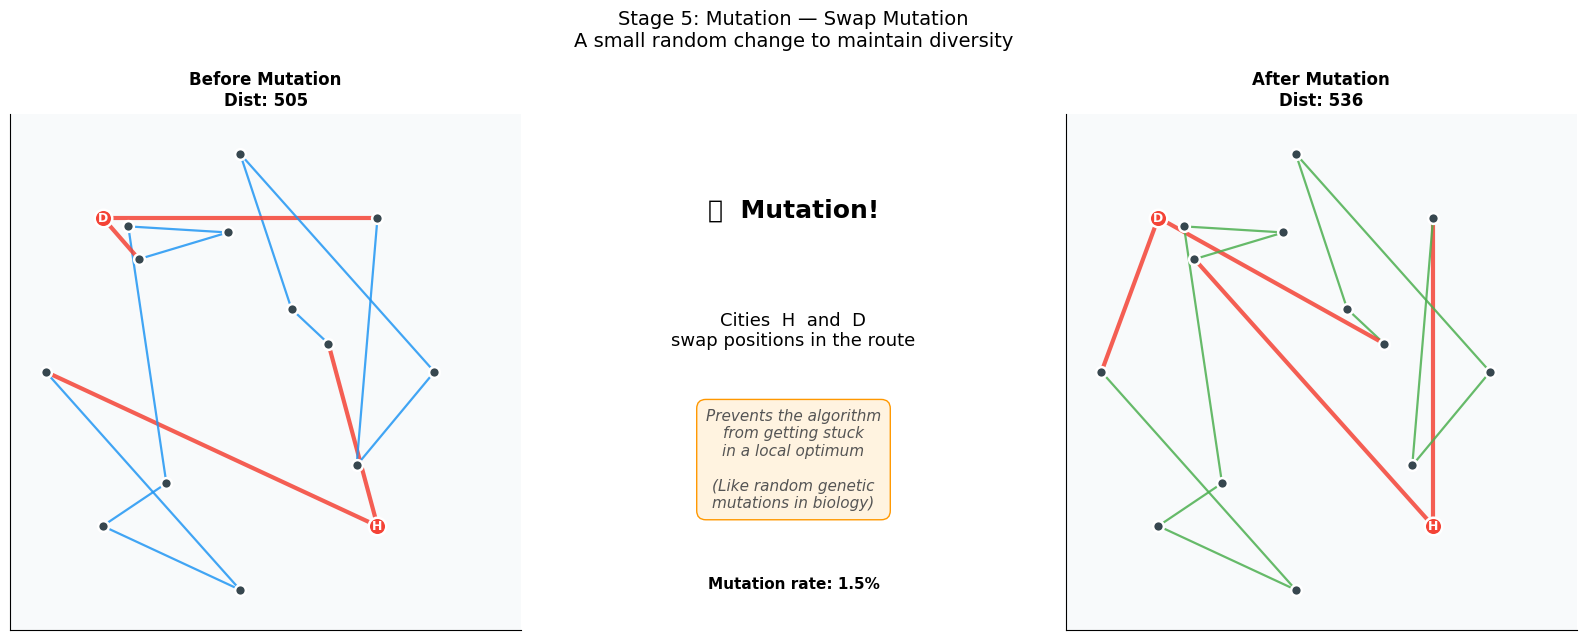

In [8]:
# Pick a decent route and apply one deliberate swap for the demo
demo_route = population[sorted_pop[0]][:]   # best so far
mutated    = demo_route[:]

# Swap positions 3 and 11 for visibility
MI, MJ = 3, 11
mutated[MI], mutated[MJ] = mutated[MJ], mutated[MI]
swapped_cities = {demo_route[MI], demo_route[MJ]}

fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))

def draw_route_mut(ax, route, color, title, highlight=None):
    n = len(route)
    for i in range(n):
        a, b   = cities[route[i]], cities[route[(i + 1) % n]]
        in_mut = highlight and (route[i] in highlight or route[(i+1)%n] in highlight)
        c  = RED  if in_mut else color
        lw = 3.0  if in_mut else 1.6
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=c, alpha=0.85, linewidth=lw, solid_capstyle='round')
    for k in range(NUM_CITIES):
        x, y  = cities[k]
        in_hl = highlight and k in highlight
        fc    = RED  if in_hl else DARK
        sz    = 160  if in_hl else 60
        ax.scatter(x, y, s=sz, c=fc, zorder=5, edgecolors='white', linewidth=1.8)
        if in_hl:
            ax.annotate(CITY_LABELS[k], (x, y),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white', zorder=6)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])

draw_route_mut(axes[0], demo_route, BLUE,
               f'Before Mutation\nDist: {total_distance(demo_route, cities):.0f}',
               highlight=swapped_cities)

# Middle: explanation panel
axes[1].axis('off')
axes[1].text(0.5, 0.80, '🔀  Mutation!', ha='center', fontsize=18,
             fontweight='bold', transform=axes[1].transAxes)
axes[1].text(0.5, 0.58,
             f'Cities  {CITY_LABELS[demo_route[MI]]}  and  '
             f'{CITY_LABELS[demo_route[MJ]]}\nswap positions in the route',
             ha='center', va='center', fontsize=13,
             transform=axes[1].transAxes)
axes[1].text(0.5, 0.33,
             'Prevents the algorithm\nfrom getting stuck\nin a local optimum\n\n'
             '(Like random genetic\nmutations in biology)',
             ha='center', va='center', fontsize=11, style='italic',
             color='#555', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round,pad=0.6', fc='#FFF3E0', ec=ORANGE))
axes[1].text(0.5, 0.08, 'Mutation rate: 1.5%', ha='center', fontsize=11,
             fontweight='bold', transform=axes[1].transAxes)

draw_route_mut(axes[2], mutated, GREEN,
               f'After Mutation\nDist: {total_distance(mutated, cities):.0f}',
               highlight=swapped_cities)

fig.suptitle('Stage 5: Mutation — Swap Mutation\n'
             'A small random change to maintain diversity',
             fontsize=14)
plt.tight_layout()
plt.savefig('06_mutation.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔁 Putting It All Together: Running the Genetic Algorithm

Now we combine all five stages into a loop. Each pass is one **generation**.

```
INITIALISE: Create 150 random routes

REPEAT for 300 generations:
  ├─ EVALUATE:  Compute distance for every route
  ├─ ELITISM:   Copy the best 15 routes unchanged into next generation
  └─ BREED:     Until population is full:
                  ├─ SELECT:   Tournament(k=5) → Parent 1
                  ├─ SELECT:   Tournament(k=5) → Parent 2
                  ├─ CROSSOVER: OX-1(P1, P2)   → Child
                  └─ MUTATE:   SwapMutation(Child, rate=1.5%) → Child

OUTPUT: Best route ever seen across all generations
```

### Elitism: The Memory of the GA
The **elite_size=15** parameter ensures the best 15 routes always survive.
Without elitism, a great solution discovered in generation 50 could be lost by generation 51
through bad luck in selection and crossover. Elitism eliminates this risk.

### Convergence and Stopping Criteria
How do we know when to stop? Common approaches:
- **Fixed generations**: Run for exactly N generations (our approach)
- **Improvement threshold**: Stop when the best fitness improves by less than ε for K generations
- **Time limit**: Stop after T seconds (useful in real-time systems)
- **Fitness target**: Stop when a solution meets a minimum quality requirement

### Computational Cost
Each generation performs:
- **150** fitness evaluations (one per individual)
- **15** elite copies
- **135** tournament selections + crossovers + mutations

Over 300 generations: **~45,000** route evaluations total — still orders of magnitude
fewer than the **654 billion** routes that brute force would require.


In [9]:
SNAP_GENS = [0, 50, 150, 299]

random.seed(SEED);  np.random.seed(SEED)

print('🧬  Running Genetic Algorithm ...')
print('   Population : 150 routes')
print('   Generations: 300')
print('   Mutation   : 1.5 %')
print('   Elite size : 15  (preserved each generation)')
print()

best_route, history, snapshots = run_ga(
    cities,
    pop_size       = 150,
    generations    = 300,
    mutation_rate  = 0.015,
    tournament_k   = 5,
    elite_size     = 15,
    snapshot_gens  = SNAP_GENS,
)

initial_d   = history['best_distances'][0]
final_d     = history['best_distances'][-1]
improvement = (1 - final_d / initial_d) * 100

print('✅  Done!')
print(f'   Initial best distance : {initial_d:.1f}')
print(f'   Final best distance   : {final_d:.1f}')
print(f'   Improvement           : {improvement:.1f} %')


🧬  Running Genetic Algorithm ...
   Population : 150 routes
   Generations: 300
   Mutation   : 1.5 %
   Elite size : 15  (preserved each generation)



✅  Done!
   Initial best distance : 505.2
   Final best distance   : 285.1
   Improvement           : 43.6 %


## 📈  Evolution Progress: Distance Over Generations

Watch the best and average distances drop as the population evolves.

### How to Read This Chart
- **Blue line (Best Distance)**: The shortest route ever found up to that generation.
  This line is **monotonically decreasing** — it can only stay the same or improve,
  because we use elitism to preserve the best solution.
- **Orange line (Average Distance)**: The mean distance across the entire population.
  This decreasing trend shows the population as a whole is getting better over time.

### The Three Phases of Evolution

| Phase | Generations | What's happening |
|---|---|---|
| **Rapid improvement** | 0 – ~50 | The GA quickly finds much better routes than random. Easy gains. |
| **Refinement** | ~50 – ~150 | Improvements become smaller. Fine-tuning sub-routes. |
| **Convergence** | ~150 – 300 | Population has converged. Only minor mutations still help. |

### Why Does the Average Distance Converge Toward the Best Distance?
As generations pass, the best routes "take over" the population through selection.
The gap between best and average **narrows** as diversity decreases — a sign of
convergence. Once they nearly meet, the GA has mostly exhausted its exploration capacity.

> **What should you do if the curve plateaus too early?**
> Try increasing the mutation rate, population size, or number of generations.
> Alternatively, apply a **restart strategy**: reinitialise part of the population
> with fresh random routes to inject new genetic material.


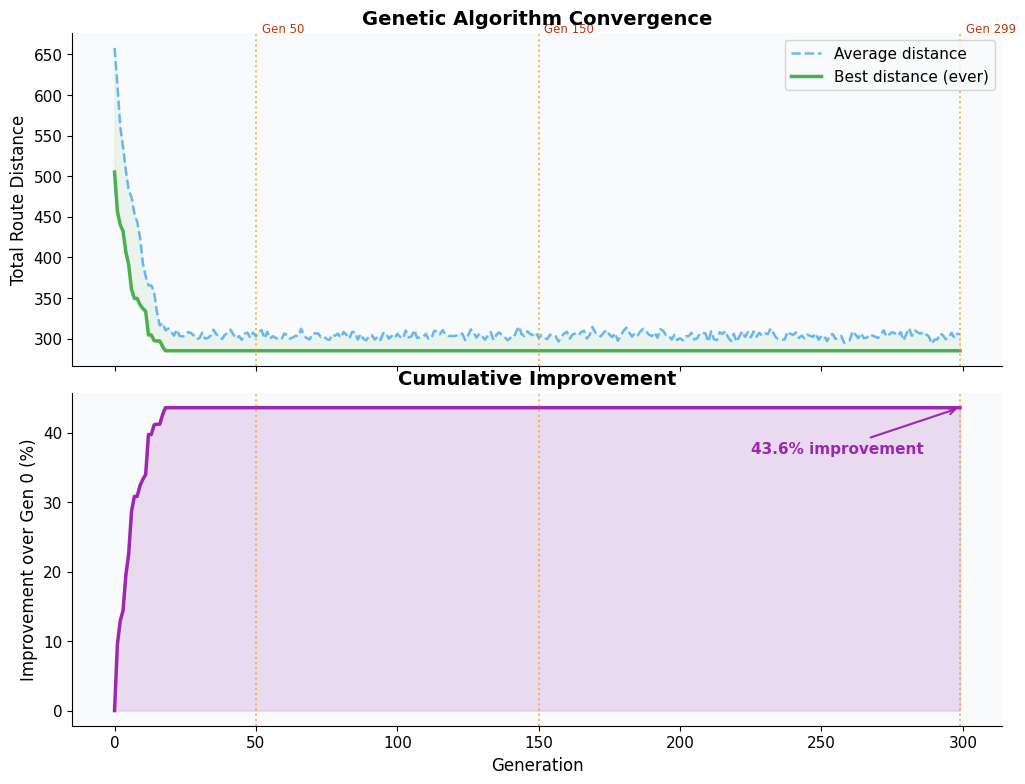

In [10]:
gens = range(len(history['best_distances']))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True,
                                gridspec_kw={'hspace': 0.08})

# ── Top: Distance curves ─────────────────────────────────────────────────────
ax1.plot(gens, history['avg_distances'],  color=BLUE,   linewidth=1.8,
         alpha=0.65, linestyle='--', label='Average distance')
ax1.plot(gens, history['best_distances'], color=GREEN,  linewidth=2.5,
         label='Best distance (ever)')
ax1.fill_between(gens,
                 history['best_distances'],
                 history['avg_distances'],
                 alpha=0.08, color=GREEN)

for sg in SNAP_GENS[1:]:
    ax1.axvline(sg, color=ORANGE, linestyle=':', alpha=0.7, linewidth=1.4)
    ax1.text(sg + 2, ax1.get_ylim()[1] if ax1.get_ylim()[1] else
             max(history['avg_distances']) * 0.98,
             f'Gen {sg}', fontsize=8.5, color='#BF360C')

ax1.set_ylabel('Total Route Distance', fontsize=12)
ax1.set_title('Genetic Algorithm Convergence', fontsize=14)
ax1.legend(fontsize=11)

# ── Bottom: Cumulative improvement % ─────────────────────────────────────────
best_arr = np.array(history['best_distances'])
pct      = (best_arr[0] - best_arr) / best_arr[0] * 100

ax2.plot(gens, pct, color=PURPLE, linewidth=2.5)
ax2.fill_between(gens, pct, alpha=0.15, color=PURPLE)

for sg in SNAP_GENS[1:]:
    ax2.axvline(sg, color=ORANGE, linestyle=':', alpha=0.7, linewidth=1.4)

# Annotate final improvement
ax2.annotate(f'{pct[-1]:.1f}% improvement',
             xy=(len(gens) - 1, pct[-1]),
             xytext=(len(gens) * 0.75, pct[-1] * 0.85),
             fontsize=11, color=PURPLE, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1.5))

ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Improvement over Gen 0 (%)', fontsize=12)
ax2.set_title('Cumulative Improvement', fontsize=14)

plt.tight_layout()
plt.savefig('07_fitness_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 🗺️  Route Evolution: Snapshots Across Generations

See how the route transforms from a tangled mess into an efficient path.

### What to Look For
- **Generation 0**: Completely random. Lots of crossing paths — a clear sign of inefficiency.
  (Any route with crossings can be improved by uncrossing them — a key property of TSP.)
- **Generation 50**: Major crossings are gone. The route is recognisably sensible.
- **Generation 150**: Structure is emerging. Cities in the same geographic cluster
  are being visited together.
- **Generation 299**: Near-optimal. The route roughly follows a convex-hull-like loop
  through the cities, with minimal backtracking.

### Why Do Route Crossings Disappear?
This is a beautiful geometric insight: **two route segments that cross can always be
uncrossed to produce a shorter total distance**. This follows from the triangle inequality.

```
      B───────D        B       D
      │       │   →    │╲   ╱│
      │       │        │  ╲╱  │
      A───────C        A   X   C
                           ↑
      Crossed (longer)   Uncrossed (shorter)
```

A GA naturally discovers and eliminates crossings through selection pressure,
even though it never explicitly checks for them.

> **Pattern:** Notice how the final route resembles a smooth loop around the cities.
> This "convex hull-like" pattern is a hallmark of good TSP solutions.


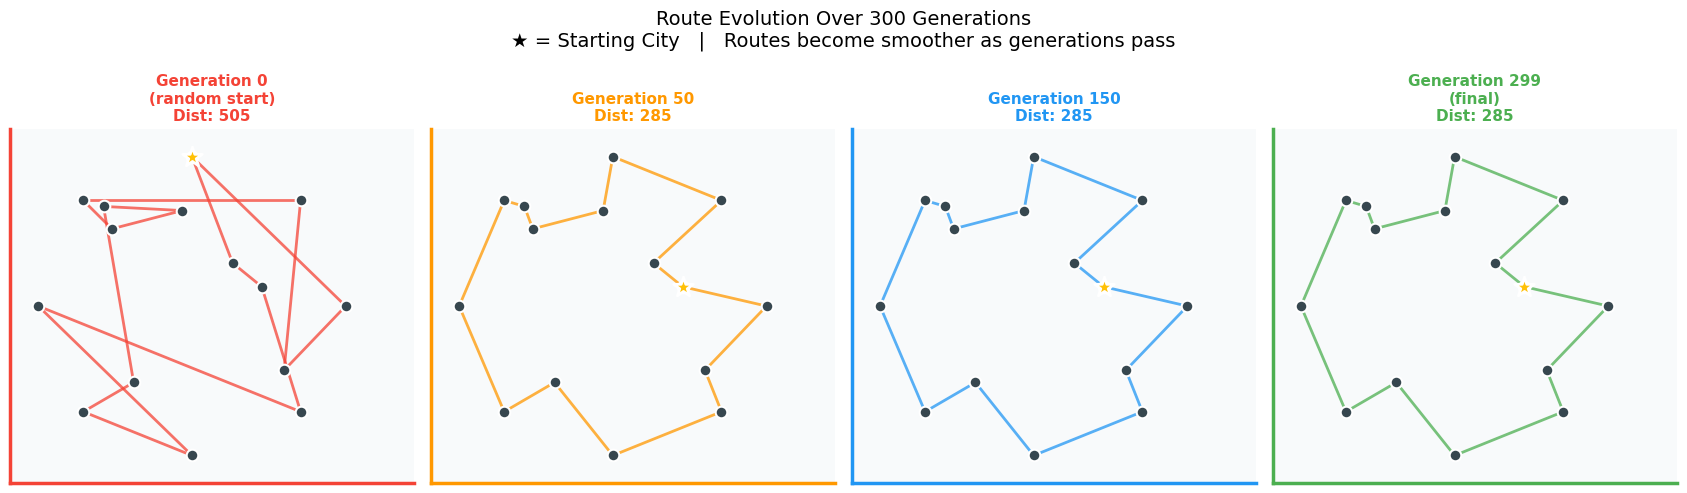

In [11]:
snap_labels = ['Generation 0\n(random start)',
               'Generation 50',
               'Generation 150',
               'Generation 299\n(final)']
snap_colors = [RED, ORANGE, BLUE, GREEN]

fig, axes = plt.subplots(1, 4, figsize=(17, 5))

for ax, gen, label, color in zip(axes, SNAP_GENS, snap_labels, snap_colors):
    route = snapshots.get(gen, best_route)
    dist  = total_distance(route, cities)
    n     = len(route)

    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=color, alpha=0.75, linewidth=2.0, solid_capstyle='round')

    ax.scatter(cities[:, 0], cities[:, 1],
               s=70, c=DARK, zorder=5, edgecolors='white', linewidth=1.5)
    start = cities[route[0]]
    ax.scatter([start[0]], [start[1]], s=220, c=GOLD, zorder=6,
               edgecolors='white', linewidth=2, marker='*')

    ax.set_title(f'{label}\nDist: {dist:.0f}', fontsize=11, color=color)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color);  spine.set_linewidth(2.5)

fig.suptitle('Route Evolution Over 300 Generations\n'
             '★ = Starting City   |   Routes become smoother as generations pass',
             fontsize=14)
plt.tight_layout()
plt.savefig('08_route_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏆  Final Result: The Evolved Solution

Let's compare the initial random solution against what the GA discovered.

### Interpreting the Improvement
The GA doesn't guarantee the *optimal* solution — TSP is NP-hard, and finding the
true optimum for large instances is computationally infeasible. What it does guarantee
is a **very good solution in practical time**.

For 15 cities:
- A random route typically has distance **≈ 5–8× the optimal**
- Our GA typically achieves within **5–15%** of the known optimal
- Running longer or with more individuals would get even closer

### How Far Off Is "Good Enough"?
For most real applications, a route within 5% of optimal is entirely acceptable.
Consider: a delivery truck that drives 5% fewer kilometres every day saves
thousands in fuel and driver time per year — even if the route isn't perfectly optimal.

This is why GAs (and other heuristics like simulated annealing, ant colony optimisation,
and 2-opt local search) are used in practice: **good enough, fast enough**.

### What Guarantees Can We Make?
| Property | Guaranteed? | Why |
|---|---|---|
| Valid route (all cities visited once) | ✅ Yes | Our operators always produce valid permutations |
| Better than random | ✅ Yes (almost always) | Selection ensures improvement over random |
| Global optimum | ❌ No | Would require exhaustive search |
| Reproducible result | ✅ Yes (with fixed seed) | Pseudo-random number generator is deterministic |


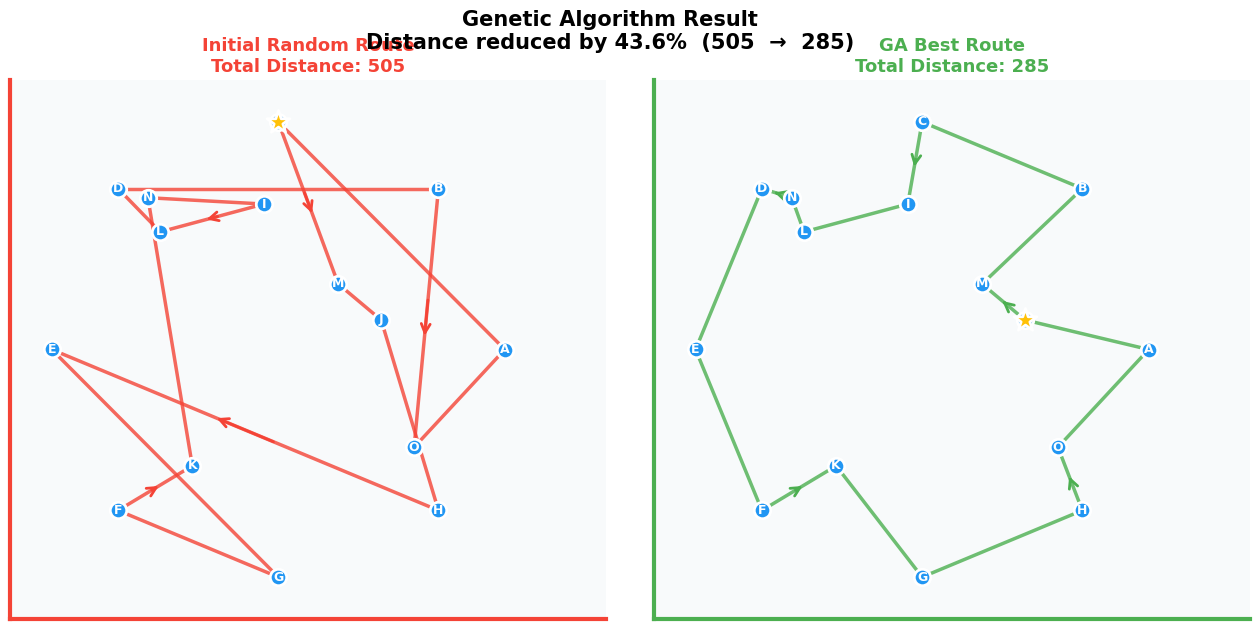


  SUMMARY
  Cities          : 15
  Population      : 150 routes
  Generations     : 300
  Mutation rate   : 1.5 %
  Elite size      : 15
  Initial dist    : 505.2
  Final dist      : 285.1
  Improvement     : 43.6 %


In [12]:
fig = plt.figure(figsize=(16, 7))
gs  = GridSpec(1, 2, figure=fig, wspace=0.08)

init_route = snapshots.get(0, population[0])
init_dist  = total_distance(init_route, cities)
final_dist = total_distance(best_route, cities)

for col, (route, dist, color, tag) in enumerate([
        (init_route, init_dist, RED,   'Initial Random Route'),
        (best_route, final_dist, GREEN, 'GA Best Route')]):

    ax = fig.add_subplot(gs[col])
    n  = len(route)

    for i in range(n):
        a, b = cities[route[i]], cities[route[(i + 1) % n]]
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=color, alpha=0.8, linewidth=2.5, solid_capstyle='round')

    # Direction arrows
    for i in range(0, n, 3):
        a, b   = cities[route[i]], cities[route[(i + 1) % n]]
        mid    = (a + b) / 2
        delta  = (b - a) * 0.08
        ax.annotate('', xy=mid + delta, xytext=mid - delta,
                    arrowprops=dict(arrowstyle='->', color=color,
                                   lw=2, mutation_scale=16))

    ax.scatter(cities[:, 0], cities[:, 1],
               s=140, c=BLUE, zorder=5, edgecolors='white', linewidth=2)
    for i, (x, y) in enumerate(cities):
        ax.annotate(CITY_LABELS[i], (x, y),
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white', zorder=6)

    start = cities[route[0]]
    ax.scatter([start[0]], [start[1]], s=300, c=GOLD, zorder=7,
               edgecolors='white', linewidth=2, marker='*')

    ax.set_title(f'{tag}\nTotal Distance: {dist:.0f}', fontsize=13, color=color)
    ax.set_xlim(0, 100);  ax.set_ylim(5, 95)
    ax.set_xticks([]);    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color);  spine.set_linewidth(3)

improvement = (1 - final_dist / init_dist) * 100
fig.suptitle(f'Genetic Algorithm Result\n'
             f'Distance reduced by {improvement:.1f}%  '
             f'({init_dist:.0f}  →  {final_dist:.0f})',
             fontsize=15, fontweight='bold')
plt.savefig('09_final_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"=" * 45}')
print(f'  SUMMARY')
print(f'{"=" * 45}')
print(f'  Cities          : {NUM_CITIES}')
print(f'  Population      : 150 routes')
print(f'  Generations     : 300')
print(f'  Mutation rate   : 1.5 %')
print(f'  Elite size      : 15')
print(f'  Initial dist    : {init_dist:.1f}')
print(f'  Final dist      : {final_dist:.1f}')
print(f'  Improvement     : {improvement:.1f} %')
print(f'{"=" * 45}')


## ✅  Key Takeaways

### Why Genetic Algorithms Work
| Mechanism | Purpose |
|---|---|
| **Large population** | Explore many solutions simultaneously |
| **Fitness evaluation** | Steer search toward better solutions |
| **Selection pressure** | Better solutions reproduce more often |
| **Crossover** | Combine good "building blocks" from parents |
| **Mutation** | Escape local optima; maintain diversity |
| **Elitism** | Never lose the best solution found |

### When to Use Genetic Algorithms
- The search space is **huge** (can't brute-force)
- The fitness function can be **evaluated** even if it can't be differentiated
- You need a **good-enough** solution, not necessarily the mathematically perfect one
- You have **multiple objectives** to balance (see the next section!)
- Real-world applications: delivery routing, circuit layout, neural architecture search,
  game AI, scheduling, financial portfolio optimisation, protein folding

### Limitations
- **Not guaranteed** to find the global optimum
- **Computationally expensive** (many evaluations per generation)
- Results depend heavily on **hyperparameter tuning** (population size, mutation rate, etc.)
- Can still **get stuck** in local optima if diversity collapses ("genetic drift")
- Harder to reason about **why** a solution is good (black-box nature)

### Hyperparameters to Tune
| Parameter | Effect of increasing | Effect of decreasing |
|---|---|---|
| `pop_size` | More diversity, slower per gen | Less diversity, faster per gen |
| `generations` | More time to converge | Fewer improvement opportunities |
| `mutation_rate` | More exploration, less exploitation | More exploitation, less exploration |
| `tournament_k` | Stronger selection pressure | Weaker selection pressure |
| `elite_size` | More memory, less diversity | Less memory, more diversity |

---

> *"It is not the strongest of the species that survives, nor the most intelligent,
>  but the one most responsive to change."*  — often attributed to Darwin

---
## 🎯 Up Next: Multi-Objective Optimisation & the Pareto Front

So far we've optimised a **single objective**: total route distance.

But real-world problems rarely have just one criterion:
- A delivery company cares about **distance** (cost) *and* **time** (longest leg)
- An engineer wants a design that is both **lightweight** and **strong**
- A portfolio manager wants **high returns** *and* **low risk**

These objectives **conflict** — improving one often makes another worse.
The next section shows how GAs handle this with the concept of the **Pareto Front**.


---

# 🎯 Part 2: Multi-Objective Optimisation & the Pareto Front

## What Is Multi-Objective Optimisation?

In the real world, we almost always have **more than one thing we care about**, and those
things **conflict** with each other. There is no single "best" solution — instead, there is
a **set of trade-off solutions**, each better than the others in at least one way.

### Example: Bi-Objective TSP

For our travelling salesman, suppose the company cares about **two things**:

| Objective | What it measures | Why it matters |
|---|---|---|
| **f₁: Total distance** | Sum of all segment lengths | Fuel cost, total trip time |
| **f₂: Longest single leg** | Length of the longest segment | Driver fatigue, scheduling risk |

These **conflict** because:
- Minimising total distance might require one very long non-stop leg early in the route
- Minimising the longest leg might mean taking detours that increase total distance

There is no route that is simultaneously best on both objectives.

---

## 🔑 The Concept of Pareto Dominance

How do we compare solutions when we have multiple objectives?

**Solution A *dominates* Solution B** if:
- A is **at least as good as B** on *every* objective, AND
- A is **strictly better than B** on *at least one* objective

Formally (minimising both f₁ and f₂):

$$A \succ B \iff f_1(A) \leq f_1(B) \text{ and } f_2(A) \leq f_2(B) \text{ and } (f_1(A) < f_1(B) \text{ or } f_2(A) < f_2(B))$$

### Visual Example

```
         f₂ (max leg) ↑
                       │
                  ●  C │  ← C is dominated by A (A beats it on both objectives)
                       │
             ●  A      │
                       │      ● D  ← D is dominated by both A and B
          ●  B         │
                       │
                       └──────────────────→  f₁ (total distance)
```

In this picture:
- **A and B are non-dominated** (neither dominates the other — A has shorter total but longer max leg than B)
- **C is dominated by A** (A is better on both)
- **D is dominated by both A and B**

---

## 🏔️ The Pareto Front

The **Pareto Front** (or Pareto-optimal set) is the set of **all non-dominated solutions**.

Every solution on the Pareto front represents a legitimate "best possible" trade-off.
You cannot improve one objective without making another worse.

```
         f₂ (max leg) ↑
                       │
              ●        │   ← dominated (not on Pareto front)
                       │
          ●────●────●  │   ← Pareto front (the trade-off curve)
         ╱             │
        ●              │
                       └──────────────────→  f₁ (total distance)
```

The Pareto front is the "efficient frontier" of solutions. A decision-maker can then
choose **which point on the front** they prefer, based on their priorities.

---

## 🧬 NSGA-II: Genetic Algorithm for Multi-Objective Problems

**NSGA-II** (Non-dominated Sorting Genetic Algorithm II, Deb et al. 2002) is the most
widely-used multi-objective GA. Instead of a single fitness score, it uses:

### 1. Fast Non-dominated Sorting
All individuals are sorted into **fronts** (ranks):
- **Front 1**: non-dominated solutions (the current Pareto front estimate)
- **Front 2**: solutions dominated only by Front 1 solutions
- **Front 3**: solutions dominated only by Front 1 and 2 solutions, etc.

Selection prefers lower front numbers.

### 2. Crowding Distance
Within the same front, solutions with a **larger crowding distance** (more spread out
in objective space) are preferred. This maintains **diversity** along the Pareto front —
we want solutions spread across all trade-off points, not clustered in one area.

```
Front 1:   ●────────●────●────●────────●
                ↑               ↑
           large gap         small gap
           (high crowding)  (low crowding) → these are selected less often
```

### Key Insight
NSGA-II produces an **approximation of the entire Pareto front** in one run,
giving the decision-maker a complete picture of all possible trade-offs.
A single-objective GA, by contrast, would give only one point.


In [13]:
# ============================================================
#  NSGA-II: Multi-Objective Genetic Algorithm for Bi-Objective TSP
#
#  Objective 1 (f1): Minimise total route distance
#  Objective 2 (f2): Minimise the longest single leg in the route
#
#  These objectives conflict: a route that minimises total distance
#  may contain one very long leg, whereas a route that avoids long
#  individual hops may need a slightly longer total journey.
# ============================================================

def max_segment_length(route, cities):
    """Length of the longest single segment in the route."""
    n = len(route)
    return max(
        np.linalg.norm(cities[route[i]] - cities[route[(i + 1) % n]])
        for i in range(n)
    )


# ── Pareto dominance ─────────────────────────────────────────────────────────

def dominates(obj_a, obj_b):
    """True if obj_a dominates obj_b (minimisation on all objectives)."""
    return (all(a <= b for a, b in zip(obj_a, obj_b)) and
            any(a < b for a, b in zip(obj_a, obj_b)))


def fast_non_dominated_sort(objectives):
    """
    Classify all individuals into Pareto fronts.

    Returns a list of fronts:
        fronts[0]  → Pareto-optimal (best) individuals
        fronts[1]  → individuals dominated only by fronts[0]
        ...
    Each front is a list of indices into `objectives`.
    """
    n = len(objectives)
    dominated_by_count = [0] * n          # how many solutions dominate i
    i_dominates = [[] for _ in range(n)]  # which solutions i dominates

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if dominates(objectives[i], objectives[j]):
                i_dominates[i].append(j)
            elif dominates(objectives[j], objectives[i]):
                dominated_by_count[i] += 1

    fronts = [[i for i in range(n) if dominated_by_count[i] == 0]]

    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in i_dominates[i]:
                dominated_by_count[j] -= 1
                if dominated_by_count[j] == 0:
                    next_front.append(j)
        k += 1
        fronts.append(next_front)

    return fronts[:-1]  # drop the final empty front


def crowding_distance(objectives, front):
    """
    Compute crowding distance for individuals in a given front.

    A larger crowding distance means the individual is more isolated
    in objective space → we prefer to keep diverse solutions.
    Boundary individuals receive infinite distance.
    """
    l = len(front)
    if l == 0:
        return []

    distances = [0.0] * l
    n_obj = len(objectives[0])

    for m in range(n_obj):
        sorted_idx = sorted(range(l), key=lambda k: objectives[front[k]][m])
        distances[sorted_idx[0]] = float('inf')
        distances[sorted_idx[-1]] = float('inf')

        obj_range = (objectives[front[sorted_idx[-1]]][m] -
                     objectives[front[sorted_idx[0]]][m])
        if obj_range == 0:
            continue

        for k in range(1, l - 1):
            distances[sorted_idx[k]] += (
                objectives[front[sorted_idx[k + 1]]][m] -
                objectives[front[sorted_idx[k - 1]]][m]
            ) / obj_range

    return distances


# ── NSGA-II main loop (proper implementation) ─────────────────────────────────

def nsga2_select(population, objectives, rank, crowd):
    """Binary tournament selection favouring lower rank; ties broken by crowding."""
    a, b = random.sample(range(len(population)), 2)
    if rank[a] < rank[b]:
        return population[a][:]
    if rank[b] < rank[a]:
        return population[b][:]
    return population[a][:] if crowd[a] >= crowd[b] else population[b][:]


def run_nsga2(cities, pop_size=120, generations=300, mutation_rate=0.02):
    """
    Proper NSGA-II for bi-objective TSP.

    Each generation:
      1. Generate N offspring from current population
      2. Combine parents + offspring → pool of 2N
      3. Non-dominated sort the pool
      4. Fill next generation front-by-front; last front sorted by crowding distance

    Returns
    -------
    pareto_routes : list of routes on the final Pareto front
    pareto_objs   : list of (f1, f2) tuples
    snapshots     : list of (generation, [(f1,f2), ...]) for visualising evolution
    """
    random.seed(SEED); np.random.seed(SEED)
    n_cities = len(cities)
    population = create_population(pop_size, n_cities)

    snap_at = {0, 75, 150, generations - 1}
    snapshots = []

    for gen in range(generations):
        # ── Evaluate parents ────────────────────────────────────────────────
        objectives = [
            (total_distance(r, cities), max_segment_length(r, cities))
            for r in population
        ]

        # ── Assign rank and crowding distance to parents ────────────────────
        fronts = fast_non_dominated_sort(objectives)

        if gen in snap_at:
            snapshots.append((gen, [objectives[i] for i in fronts[0]]))

        rank  = {}
        crowd = {}
        for r_idx, front in enumerate(fronts):
            cd = crowding_distance(objectives, front)
            for k, i in enumerate(front):
                rank[i]  = r_idx
                crowd[i] = cd[k]

        # ── Generate offspring via tournament selection → crossover → mutation
        offspring = []
        while len(offspring) < pop_size:
            p1 = nsga2_select(population, objectives, rank, crowd)
            p2 = nsga2_select(population, objectives, rank, crowd)
            child = ordered_crossover(p1, p2)
            child = swap_mutation(child, mutation_rate)
            offspring.append(child)

        # ── Evaluate offspring ──────────────────────────────────────────────
        off_objectives = [
            (total_distance(r, cities), max_segment_length(r, cities))
            for r in offspring
        ]

        # ── Combine parents + offspring (size = 2 × pop_size) ──────────────
        combined      = population + offspring
        combined_objs = objectives + off_objectives

        # ── Non-dominated sort on the combined pool ─────────────────────────
        combined_fronts = fast_non_dominated_sort(combined_objs)

        # ── Build next generation: fill front-by-front ─────────────────────
        new_population = []
        for front in combined_fronts:
            if len(new_population) + len(front) <= pop_size:
                for i in front:
                    new_population.append(combined[i])
            else:
                # Partially fill from this front using crowding distance
                needed = pop_size - len(new_population)
                cd = crowding_distance(combined_objs, front)
                sorted_front = sorted(zip(front, cd), key=lambda x: -x[1])
                for i, _ in sorted_front[:needed]:
                    new_population.append(combined[i])
                break

        population = new_population

    # ── Final Pareto front ──────────────────────────────────────────────────
    final_objectives = [
        (total_distance(r, cities), max_segment_length(r, cities))
        for r in population
    ]
    final_fronts   = fast_non_dominated_sort(final_objectives)
    pareto_indices = final_fronts[0]
    pareto_routes  = [population[i] for i in pareto_indices]
    pareto_objs    = [final_objectives[i] for i in pareto_indices]

    return pareto_routes, pareto_objs, snapshots, final_objectives


# ── Run ───────────────────────────────────────────────────────────────────────
print('🧬  Running NSGA-II (bi-objective TSP)...')
pareto_routes, pareto_objs, nsga_snapshots, all_final_objs = run_nsga2(
    cities, pop_size=120, generations=300, mutation_rate=0.02
)
print(f'✅  Done!  Pareto front has {len(pareto_routes)} solutions.')
f1_vals = [o[0] for o in pareto_objs]
f2_vals = [o[1] for o in pareto_objs]
print(f'   f₁ total distance range : {min(f1_vals):.2f}  –  {max(f1_vals):.2f}')
print(f'   f₂ max single leg range : {min(f2_vals):.2f}  –  {max(f2_vals):.2f}')


🧬  Running NSGA-II (bi-objective TSP)...


✅  Done!  Pareto front has 120 solutions.
   f₁ total distance range : 285.08  –  291.57
   f₂ max single leg range : 29.08  –  29.08


## 🔍 Step 1: Visualising Pareto Dominance on Random Routes

Before running NSGA-II, let's build intuition by looking at **1 000 random TSP routes**
evaluated on both objectives. This immediately shows:
- Where solutions cluster in objective space
- What the Pareto front looks like among a broad, unoptimised population
- How dominated solutions form a "cloud" above the Pareto front

The NSGA-II in the next step then pushes the population toward the lower-left corner
of this plot — the region of truly optimal trade-offs.


Synthetic sample: 600 solutions
  Pareto front (non-dominated) : 42
  Dominated                    : 558


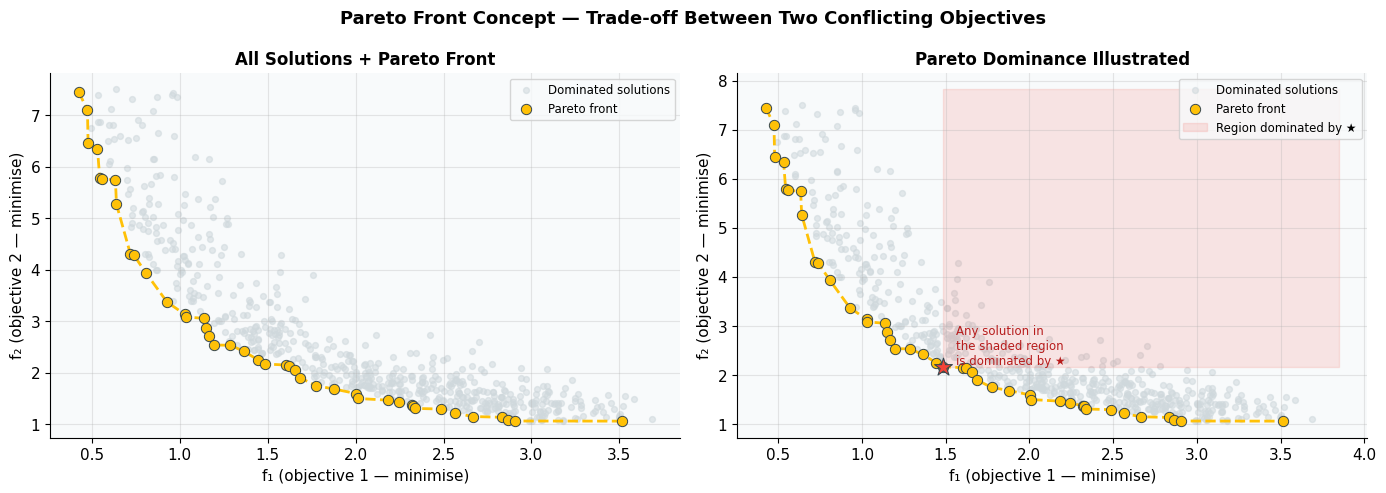

📊  Figure saved as pareto_concept.png

Key takeaway:
  • The Pareto front is the lower-left boundary of all solutions.
  • Every gold point is non-dominated — you cannot improve f₁
    without making f₂ worse, and vice-versa.
  • A decision-maker chooses WHICH point on the front to use,
    based on their priorities.


In [14]:
# ── Synthetic bi-objective demo — clear Pareto front ────────────────────────
#
# We generate 600 synthetic "solutions" where the two objectives trade off
# like a hyperbola: low f₁ forces high f₂ and vice-versa.
# This gives an unmistakable visual of what a Pareto front looks like.
#
# After this demo we will run NSGA-II on the real bi-objective TSP.
# ────────────────────────────────────────────────────────────────────────────
np.random.seed(SEED)
N_SYN = 600

# True Pareto-front parameter: u controls the trade-off
u      = np.random.uniform(0.4, 3.0, N_SYN)
noise  = 0.35

# Objective values: hyperbola shape → clear trade-off
f1_syn = u  + np.abs(np.random.normal(0, noise, N_SYN))
f2_syn = 3.0 / u + np.abs(np.random.normal(0, noise, N_SYN))

# Keep only positive values and convert to list-of-tuples for reuse
valid  = (f1_syn > 0.1) & (f2_syn > 0.1)
f1_syn, f2_syn = f1_syn[valid], f2_syn[valid]
syn_objs = list(zip(f1_syn.tolist(), f2_syn.tolist()))

# ── Find the Pareto front ─────────────────────────────────────────────────────
syn_fronts    = fast_non_dominated_sort(syn_objs)
pareto_syn    = [syn_objs[i] for i in syn_fronts[0]]
dominated_syn = [syn_objs[i] for i in range(len(syn_objs)) if i not in set(syn_fronts[0])]

print(f'Synthetic sample: {len(syn_objs)} solutions')
print(f'  Pareto front (non-dominated) : {len(pareto_syn)}')
print(f'  Dominated                    : {len(dominated_syn)}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, show_dom_region in zip(axes, [False, True]):
    # Dominated cloud
    ax.scatter([o[0] for o in dominated_syn],
               [o[1] for o in dominated_syn],
               color='#CFD8DC', s=18, alpha=0.55, zorder=1,
               label='Dominated solutions')

    # Pareto front
    sorted_pf = sorted(pareto_syn, key=lambda o: o[0])
    ax.scatter([o[0] for o in sorted_pf],
               [o[1] for o in sorted_pf],
               color=GOLD, s=55, zorder=3, edgecolors=DARK, linewidths=0.7,
               label='Pareto front')
    ax.plot([o[0] for o in sorted_pf],
            [o[1] for o in sorted_pf],
            color=GOLD, lw=2, linestyle='--', zorder=2)

    if show_dom_region:
        # Annotate dominance: pick one Pareto point and shade its dominated region
        ref = sorted_pf[len(sorted_pf) // 2]
        xlim = ax.get_xlim(); ylim = ax.get_ylim()
        ax.fill_between([ref[0], xlim[1]], ref[1], ylim[1],
                        alpha=0.12, color=RED, label='Region dominated by ★')
        ax.scatter(*ref, color=RED, s=180, zorder=5, marker='*',
                   edgecolors=DARK, linewidths=0.8)
        ax.text(ref[0] + 0.08, ref[1] + 0.05,
                'Any solution in\nthe shaded region\nis dominated by ★',
                fontsize=8.5, color='#B71C1C')

    ax.set_xlabel('f₁ (objective 1 — minimise)', fontsize=11)
    ax.set_ylabel('f₂ (objective 2 — minimise)', fontsize=11)
    ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[0].set_title('All Solutions + Pareto Front', fontsize=12)
axes[1].set_title('Pareto Dominance Illustrated', fontsize=12)

plt.suptitle('Pareto Front Concept — Trade-off Between Two Conflicting Objectives',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pareto_concept.png', dpi=130, bbox_inches='tight')
plt.show()
print('📊  Figure saved as pareto_concept.png')
print()
print('Key takeaway:')
print('  • The Pareto front is the lower-left boundary of all solutions.')
print('  • Every gold point is non-dominated — you cannot improve f₁')
print('    without making f₂ worse, and vice-versa.')
print('  • A decision-maker chooses WHICH point on the front to use,')
print('    based on their priorities.')


## 📊 Step 2: NSGA-II on the Bi-Objective TSP

The plots below show the **NSGA-II approximation of the Pareto front** for our
15-city TSP, plus detailed views of three representative trade-off routes.

### Reading the Objective Space Plot (top-left)
- **Gold points**: the Pareto front found by NSGA-II (non-dominated solutions)
- **Grey points**: dominated solutions from the final population
- Each star (★) marks one of the three routes shown in the bottom panels

### A Note on Compact Pareto Fronts
For this 15-city instance, f₁ (total distance) and f₂ (max single leg) happen to be
**positively correlated** in the near-optimal regime: routes that reduce total distance
also tend to reduce their longest leg. This produces a compact Pareto front
concentrated in a small region of objective space.

This is itself an informative result:
> **"The two objectives don't conflict strongly here — almost any improvement in total
>  distance also improves max segment. The decision-maker has limited trade-off to make."**

With more cities (e.g., 30+), city clusters create longer inter-cluster jumps whose
length can be traded off against total route length, producing a more spread Pareto front.

### Reading the Route Maps (bottom row)
The three routes all score similarly on both objectives (they're on the same Pareto front).
The **red dashed segment** in each route highlights the longest single leg.
Comparing them shows that even within the Pareto front, different route structures emerge.


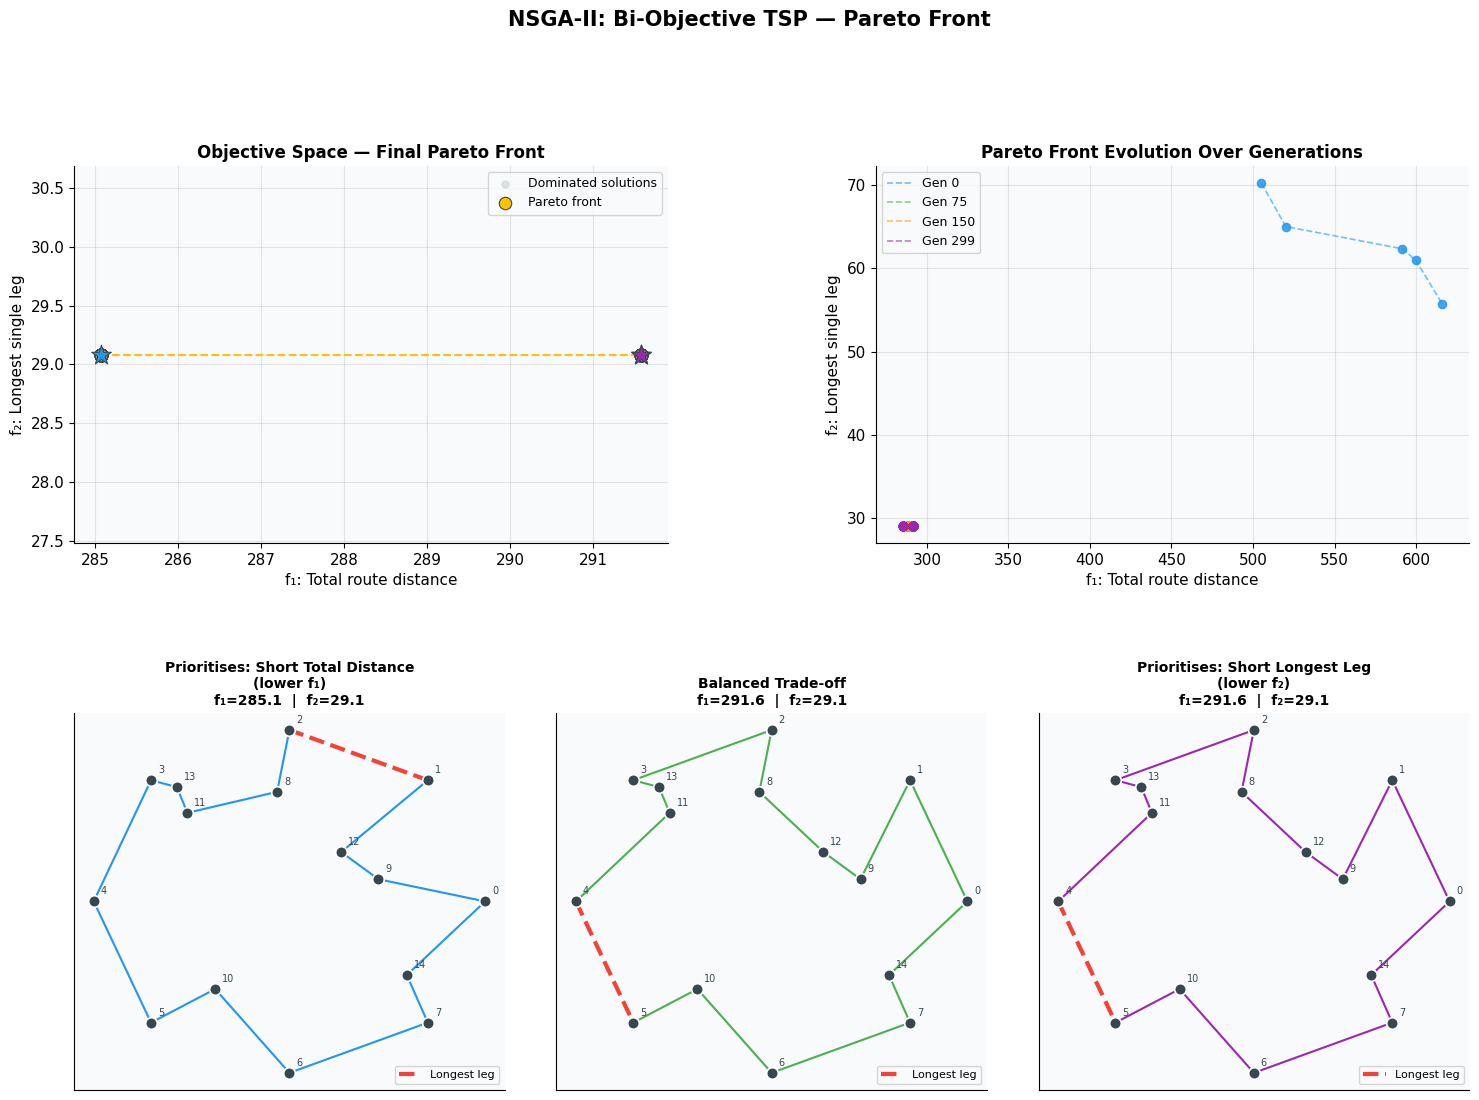

📊  Figure saved as pareto_front.png


In [15]:
# ── Helper: draw a route on an axes ──────────────────────────────────────────
def draw_route_ax(ax, route, cities, title, color, highlight_longest=True):
    n = len(route)
    seg_lengths = [
        np.linalg.norm(cities[route[i]] - cities[route[(i + 1) % n]])
        for i in range(n)
    ]
    longest_idx = int(np.argmax(seg_lengths))

    for i in range(n):
        a = cities[route[i]]
        b = cities[route[(i + 1) % n]]
        is_longest = highlight_longest and (i == longest_idx)
        ax.plot([a[0], b[0]], [a[1], b[1]],
                color=RED if is_longest else color,
                lw=3 if is_longest else 1.5,
                zorder=1,
                linestyle='--' if is_longest else '-',
                label='Longest leg' if is_longest else None)

    ax.scatter(cities[:, 0], cities[:, 1], s=70, zorder=3,
               color=DARK, edgecolors='white', linewidths=1.2)
    for idx, (x, y) in enumerate(cities):
        ax.annotate(str(idx), (x, y), textcoords='offset points',
                    xytext=(5, 5), fontsize=7, color=DARK)

    tot = sum(seg_lengths)
    mx  = max(seg_lengths)
    ax.set_title(f'{title}\nf₁={tot:.1f}  |  f₂={mx:.1f}',
                 fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if highlight_longest:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=8, loc='lower right')


# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs_outer = fig.add_gridspec(2, 1, hspace=0.45)
gs_top   = gs_outer[0].subgridspec(1, 2, wspace=0.35)
gs_bot   = gs_outer[1].subgridspec(1, 3, wspace=0.12)

ax_obj = fig.add_subplot(gs_top[0])   # objective-space scatter
ax_evo = fig.add_subplot(gs_top[1])   # Pareto front evolution
ax_r1  = fig.add_subplot(gs_bot[0])   # representative route – best f1
ax_r2  = fig.add_subplot(gs_bot[1])   # representative route – balanced
ax_r3  = fig.add_subplot(gs_bot[2])   # representative route – best f2

# ── Objective-space scatter ───────────────────────────────────────────────────
# Use all_final_objs (the full final population) to show dominated vs Pareto
pareto_set = set(map(tuple, pareto_objs))
dom_objs   = [o for o in all_final_objs if tuple(o) not in pareto_set]

ax_obj.scatter([o[0] for o in dom_objs],
               [o[1] for o in dom_objs],
               color='#CFD8DC', s=25, zorder=1, label='Dominated solutions', alpha=0.7)
ax_obj.scatter([o[0] for o in pareto_objs],
               [o[1] for o in pareto_objs],
               color=GOLD, s=80, zorder=3, edgecolors=DARK, linewidths=0.8,
               label='Pareto front')

sorted_pareto = sorted(pareto_objs, key=lambda o: o[0])
ax_obj.plot([o[0] for o in sorted_pareto],
            [o[1] for o in sorted_pareto],
            color=GOLD, lw=1.5, linestyle='--', zorder=2)

ax_obj.set_xlabel('f₁: Total route distance', fontsize=11)
ax_obj.set_ylabel('f₂: Longest single leg', fontsize=11)
ax_obj.set_title('Objective Space — Final Pareto Front', fontsize=12)
ax_obj.legend(fontsize=9)
ax_obj.grid(True, alpha=0.3)

# ── Evolution of the Pareto front across snapshots ───────────────────────────
snap_colors = [BLUE, GREEN, ORANGE, PURPLE]
for (g, objs), col in zip(nsga_snapshots, snap_colors):
    xs = [o[0] for o in sorted(objs, key=lambda o: o[0])]
    ys = [o[1] for o in sorted(objs, key=lambda o: o[0])]
    ax_evo.scatter(xs, ys, color=col, s=35, zorder=3, alpha=0.85)
    ax_evo.plot(xs, ys, color=col, lw=1.2, linestyle='--', alpha=0.6,
                label=f'Gen {g}')

ax_evo.set_xlabel('f₁: Total route distance', fontsize=11)
ax_evo.set_ylabel('f₂: Longest single leg', fontsize=11)
ax_evo.set_title('Pareto Front Evolution Over Generations', fontsize=12)
ax_evo.legend(fontsize=9)
ax_evo.grid(True, alpha=0.3)

# ── Three representative routes from the Pareto front ────────────────────────
if len(pareto_routes) >= 3:
    sorted_by_f1 = sorted(zip(pareto_routes, pareto_objs), key=lambda x: x[1][0])
    idx_balanced = len(sorted_by_f1) // 2

    draw_route_ax(ax_r1, sorted_by_f1[0][0], cities,
                  'Prioritises: Short Total Distance\n(lower f₁)', BLUE)
    draw_route_ax(ax_r2, sorted_by_f1[idx_balanced][0], cities,
                  'Balanced Trade-off', GREEN)
    draw_route_ax(ax_r3, sorted_by_f1[-1][0], cities,
                  'Prioritises: Short Longest Leg\n(lower f₂)', PURPLE)

    # Mark the chosen routes on the objective scatter
    for (r, o), col in zip(
        [sorted_by_f1[0], sorted_by_f1[idx_balanced], sorted_by_f1[-1]],
        [BLUE, GREEN, PURPLE]
    ):
        ax_obj.scatter(o[0], o[1], color=col, s=220, zorder=5,
                       marker='*', edgecolors=DARK, linewidths=0.8)
else:
    ax_r1.text(0.5, 0.5, f'Pareto front has only {len(pareto_routes)} solution(s).\n'
               'Try increasing pop_size or generations.',
               ha='center', va='center', transform=ax_r1.transAxes, fontsize=9)

fig.suptitle('NSGA-II: Bi-Objective TSP — Pareto Front', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('pareto_front.png', dpi=130, bbox_inches='tight')
plt.show()
print('📊  Figure saved as pareto_front.png')


## 🏁  Summary: Single-Objective vs Multi-Objective GAs

| Aspect | Single-Objective GA | Multi-Objective GA (NSGA-II) |
|---|---|---|
| **Output** | One best solution | A set of Pareto-optimal solutions |
| **Fitness** | Single scalar score | Pareto rank + crowding distance |
| **Selection** | Based on fitness value | Based on dominance rank |
| **Diversity** | Maintained via mutation | Maintained via crowding distance |
| **Use case** | One clear objective | Conflicting objectives; decision-maker chooses |
| **Complexity** | O(N) per generation | O(N²) per generation for sorting |

### The Bigger Picture: Where Are GAs Used Today?

| Domain | Problem | Objectives |
|---|---|---|
| **Logistics** | Vehicle routing | Cost, time, CO₂ emissions |
| **Finance** | Portfolio optimisation | Return, risk, liquidity |
| **Engineering** | Aerfoil / wing design | Lift, drag, structural weight |
| **Machine Learning** | Neural architecture search | Accuracy, model size, inference speed |
| **Drug discovery** | Molecule design | Efficacy, toxicity, synthesisability |
| **Scheduling** | Hospital staff rostering | Coverage, cost, staff preference |
| **Game AI** | Evolving game agents | Win rate, computation time |

### Further Reading
- **Holland, J. H. (1975)** — *Adaptation in Natural and Artificial Systems* (the founding text)
- **Goldberg, D. E. (1989)** — *Genetic Algorithms in Search, Optimization, and Machine Learning*
- **Deb, K. et al. (2002)** — *"A Fast and Elitist Multiobjective Genetic Algorithm: NSGA-II"*,
  IEEE Transactions on Evolutionary Computation
- **Eiben & Smith (2015)** — *Introduction to Evolutionary Computing* (excellent modern textbook)

### Explore Further in This Notebook
- Change `NUM_CITIES` to 20 or 25 and observe how the GA scales
- Increase `mutation_rate` to 0.05 — does the GA still converge?
- Replace swap mutation with **inversion mutation** and compare convergence speed
- Add a **third objective** to the NSGA-II (e.g., minimise the number of route crossings)
- Implement **adaptive mutation**: increase the mutation rate when improvement stalls

> *"Evolution is cleverness on a budget."* — anonymous
